# Problem Statement
In the financial industry, it is crucial for lenders to assess the creditworthiness of borrowers before granting loans or credit. Identifying potential defaulters, who are at higher risk of failing to repay their debts, can help mitigate financial losses and maintain a healthy lending portfolio.

The goal of this project is to develop a predictive model that can accurately classify borrowers as defaulters or non-defaulters based on various financial and demographic factors.

# Analytical Objective
Develop and evaluate a predictive model using machine learning techniques to classify loan borrowers as either likely to be a defaulter or not by analyzing historical data.

# Dataset Overview
Column Name | Description | Data Type | Unit
----------- | ----------- |----------- | -----
customer_id | Unique IDs of the customer | - | -
loan_id | Unique ID assigned on loan application | - | -
loan_type | Category of loan | CATEGORICAL | -
loan_amount | The total amount of loan | INT | INR (Indian Rupees)
interest_rate | Interest rate of the loan | - | PERCENT
loan_term | Term of the loan | INT | MONTHS
employment_type | Type of the employment of customer | CATEGORICAL | -
lncome_level | Income level category | CATEGORICAL | -
credit_score | Credit score of the customer | INT | -
gender | Gender of the customer | CATEGORICAL | -
marital_status | Marital Status of the customer | CATEGORICAL | -
education_level | Education level of the customer | CATEGORICAL | -
application_date | The date of the application from the customer | DATE | -
approval_date | The approval date from the company | DATE | -
disbursement_date | The disbursement dates | DATE | -
due_date | The due date for the loan | DATE | -
default_status | Default status (Target) | BINARY | -

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# plotting theme
sns.set_theme(style="whitegrid", palette="colorblind")

In [3]:
# read in file into pandas dataframe
loan_df = pd.read_csv("../DATA/RAW/loan.csv")
loan_df

,customer_id,loan_id,loan_type,loan_amount,interest_rate,loan_term,employment_type,income_level,credit_score,gender,marital_status,education_level,application_date,approval_date,disbursement_date,due_date,default_status
0,CUST-00004912,LN00004170,Car Loan,16795,0.051852,15,Self-employed,Medium,833,Male,Single,Master,05-04-2018,23-04-2018,24-04-2018,14-08-2018,False
1,CUST-00004194,LN00002413,Personal Loan,1860,0.089296,56,Full-time,Medium,776,Female,Married,Bachelor,30-12-2022,31-12-2022,12-01-2023,05-04-2023,False
2,CUST-00003610,LN00000024,Personal Loan,77820,0.070470,51,Full-time,Low,697,Male,Divorced,High School,15-11-2019,18-11-2019,27-11-2019,24-02-2020,False
3,CUST-00001895,LN00001742,Car Loan,55886,0.062155,30,Full-time,Low,795,Female,Married,PhD,25-08-2021,08-09-2021,11-09-2021,25-02-2022,False
4,CUST-00003782,LN00003161,Home Loan,7265,0.070635,48,Part-time,Low,519,Female,Married,High School,02-09-2020,07-09-2020,11-09-2020,29-12-2020,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST-00002992,LN00001103,Car Loan,37945,0.070087,57,Self-employed,High,511,Male,Married,PhD,23-01-2022,11-02-2022,14-02-2022,13-06-2022,False
4996,CUST-00004094,LN00001068,Personal Loan,48937,0.056405,50,Part-time,Medium,502,Male,Single,PhD,12-05-2018,17-05-2018,27-05-2018,20-11-2018,False
4997,CUST-00003903,LN00000745,Home Loan,7476,0.064212,58,Full-time,High,452,Female,Single,High School,14-10-2022,29-10-2022,06-11-2022,08-04-2023,True
4998,CUST-00002276,LN00003075,Car Loan,52756,0.094914,12,Self-employed,Medium,728,Male,Married,PhD,21-07-2018,06-08-2018,20-08-2018,21-01-2019,False


## DataFrame Inspection

In [4]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5000 non-null   object 
 1   loan_id            5000 non-null   object 
 2   loan_type          5000 non-null   object 
 3   loan_amount        5000 non-null   int64  
 4   interest_rate      5000 non-null   float64
 5   loan_term          5000 non-null   int64  
 6   employment_type    5000 non-null   object 
 7   income_level       5000 non-null   object 
 8   credit_score       5000 non-null   int64  
 9   gender             5000 non-null   object 
 10  marital_status     5000 non-null   object 
 11  education_level    5000 non-null   object 
 12  application_date   5000 non-null   object 
 13  approval_date      5000 non-null   object 
 14  disbursement_date  5000 non-null   object 
 15  due_date           5000 non-null   object 
 16  default_status     5000 

All four date columns `application_date` , `approval_date`, `disbursement_date`, and `due_date` are stored with incorrect data types

In [5]:
# duplicate check
loan_df.duplicated().sum()

np.int64(0)

In [6]:
# statistical summary
loan_df.describe()

,loan_amount,interest_rate,loan_term,credit_score
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,49929.868000,0.079579,35.263000,573.206000
std,28721.249529,0.015230,13.792501,158.647522
min,1055.000000,0.031685,12.000000,300.000000
25%,24953.500000,0.069240,24.000000,435.000000
50%,49730.000000,0.079533,35.000000,571.000000
75%,75083.500000,0.089984,47.000000,712.000000
max,99989.000000,0.138894,59.000000,849.000000


In [7]:
loan_df.describe(exclude="number")

,customer_id,loan_id,loan_type,employment_type,income_level,gender,marital_status,education_level,application_date,approval_date,disbursement_date,due_date,default_status
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,3121,3159,4,3,3,2,3,4,1711,1732,1723,1764,2
top,CUST-00000917,LN00002422,Personal Loan,Part-time,Low,Male,Divorced,PhD,16-10-2019,27-01-2020,09-06-2020,04-03-2022,False
freq,7,5,1281,1672,1713,2542,1682,1282,10,10,12,10,4001


In [8]:
# check for inconsistent text value
cat_col = ["loan_type", "employment_type", "income_level", "gender", "marital_status", "education_level"]

for col in cat_col:
    print(loan_df[col].value_counts())
    print("--" * 30)

loan_type
Personal Loan     1281
Car Loan          1273
Home Loan         1264
Education Loan    1182
Name: count, dtype: int64
------------------------------------------------------------
employment_type
Part-time        1672
Self-employed    1669
Full-time        1659
Name: count, dtype: int64
------------------------------------------------------------
income_level
Low       1713
Medium    1672
High      1615
Name: count, dtype: int64
------------------------------------------------------------
gender
Male      2542
Female    2458
Name: count, dtype: int64
------------------------------------------------------------
marital_status
Divorced    1682
Married     1681
Single      1637
Name: count, dtype: int64
------------------------------------------------------------
education_level
PhD            1282
Master         1254
Bachelor       1254
High School    1210
Name: count, dtype: int64
------------------------------------------------------------


All textual vaues are consistent

## Data Cleaning

In [9]:
# Assign proper data type to colu,mns
date_col = ["application_date", "approval_date", "disbursement_date", "due_date"]

for col in date_col:
    loan_df[col] = pd.to_datetime(loan_df[col], format="mixed", dayfirst=True)

In [10]:
loan_df.dtypes

customer_id                  object
loan_id                      object
loan_type                    object
loan_amount                   int64
interest_rate               float64
loan_term                     int64
employment_type              object
income_level                 object
credit_score                  int64
gender                       object
marital_status               object
education_level              object
application_date     datetime64[ns]
approval_date        datetime64[ns]
disbursement_date    datetime64[ns]
due_date             datetime64[ns]
default_status                 bool
dtype: object

## Exploratory Data Analysis

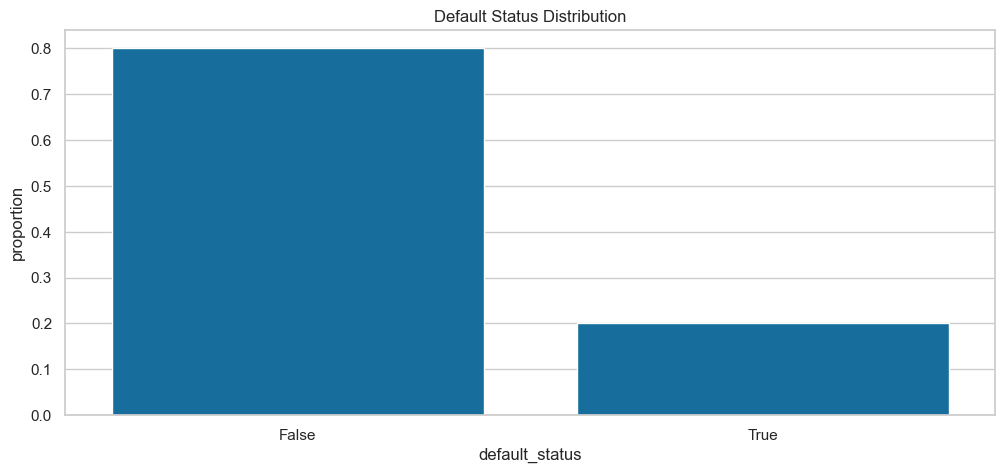

In [11]:
# Exploring the target
plt.figure(figsize=(12, 5))
sns.countplot(data=loan_df, x="default_status", stat="proportion").set(
    title="Default Status Distribution"
);

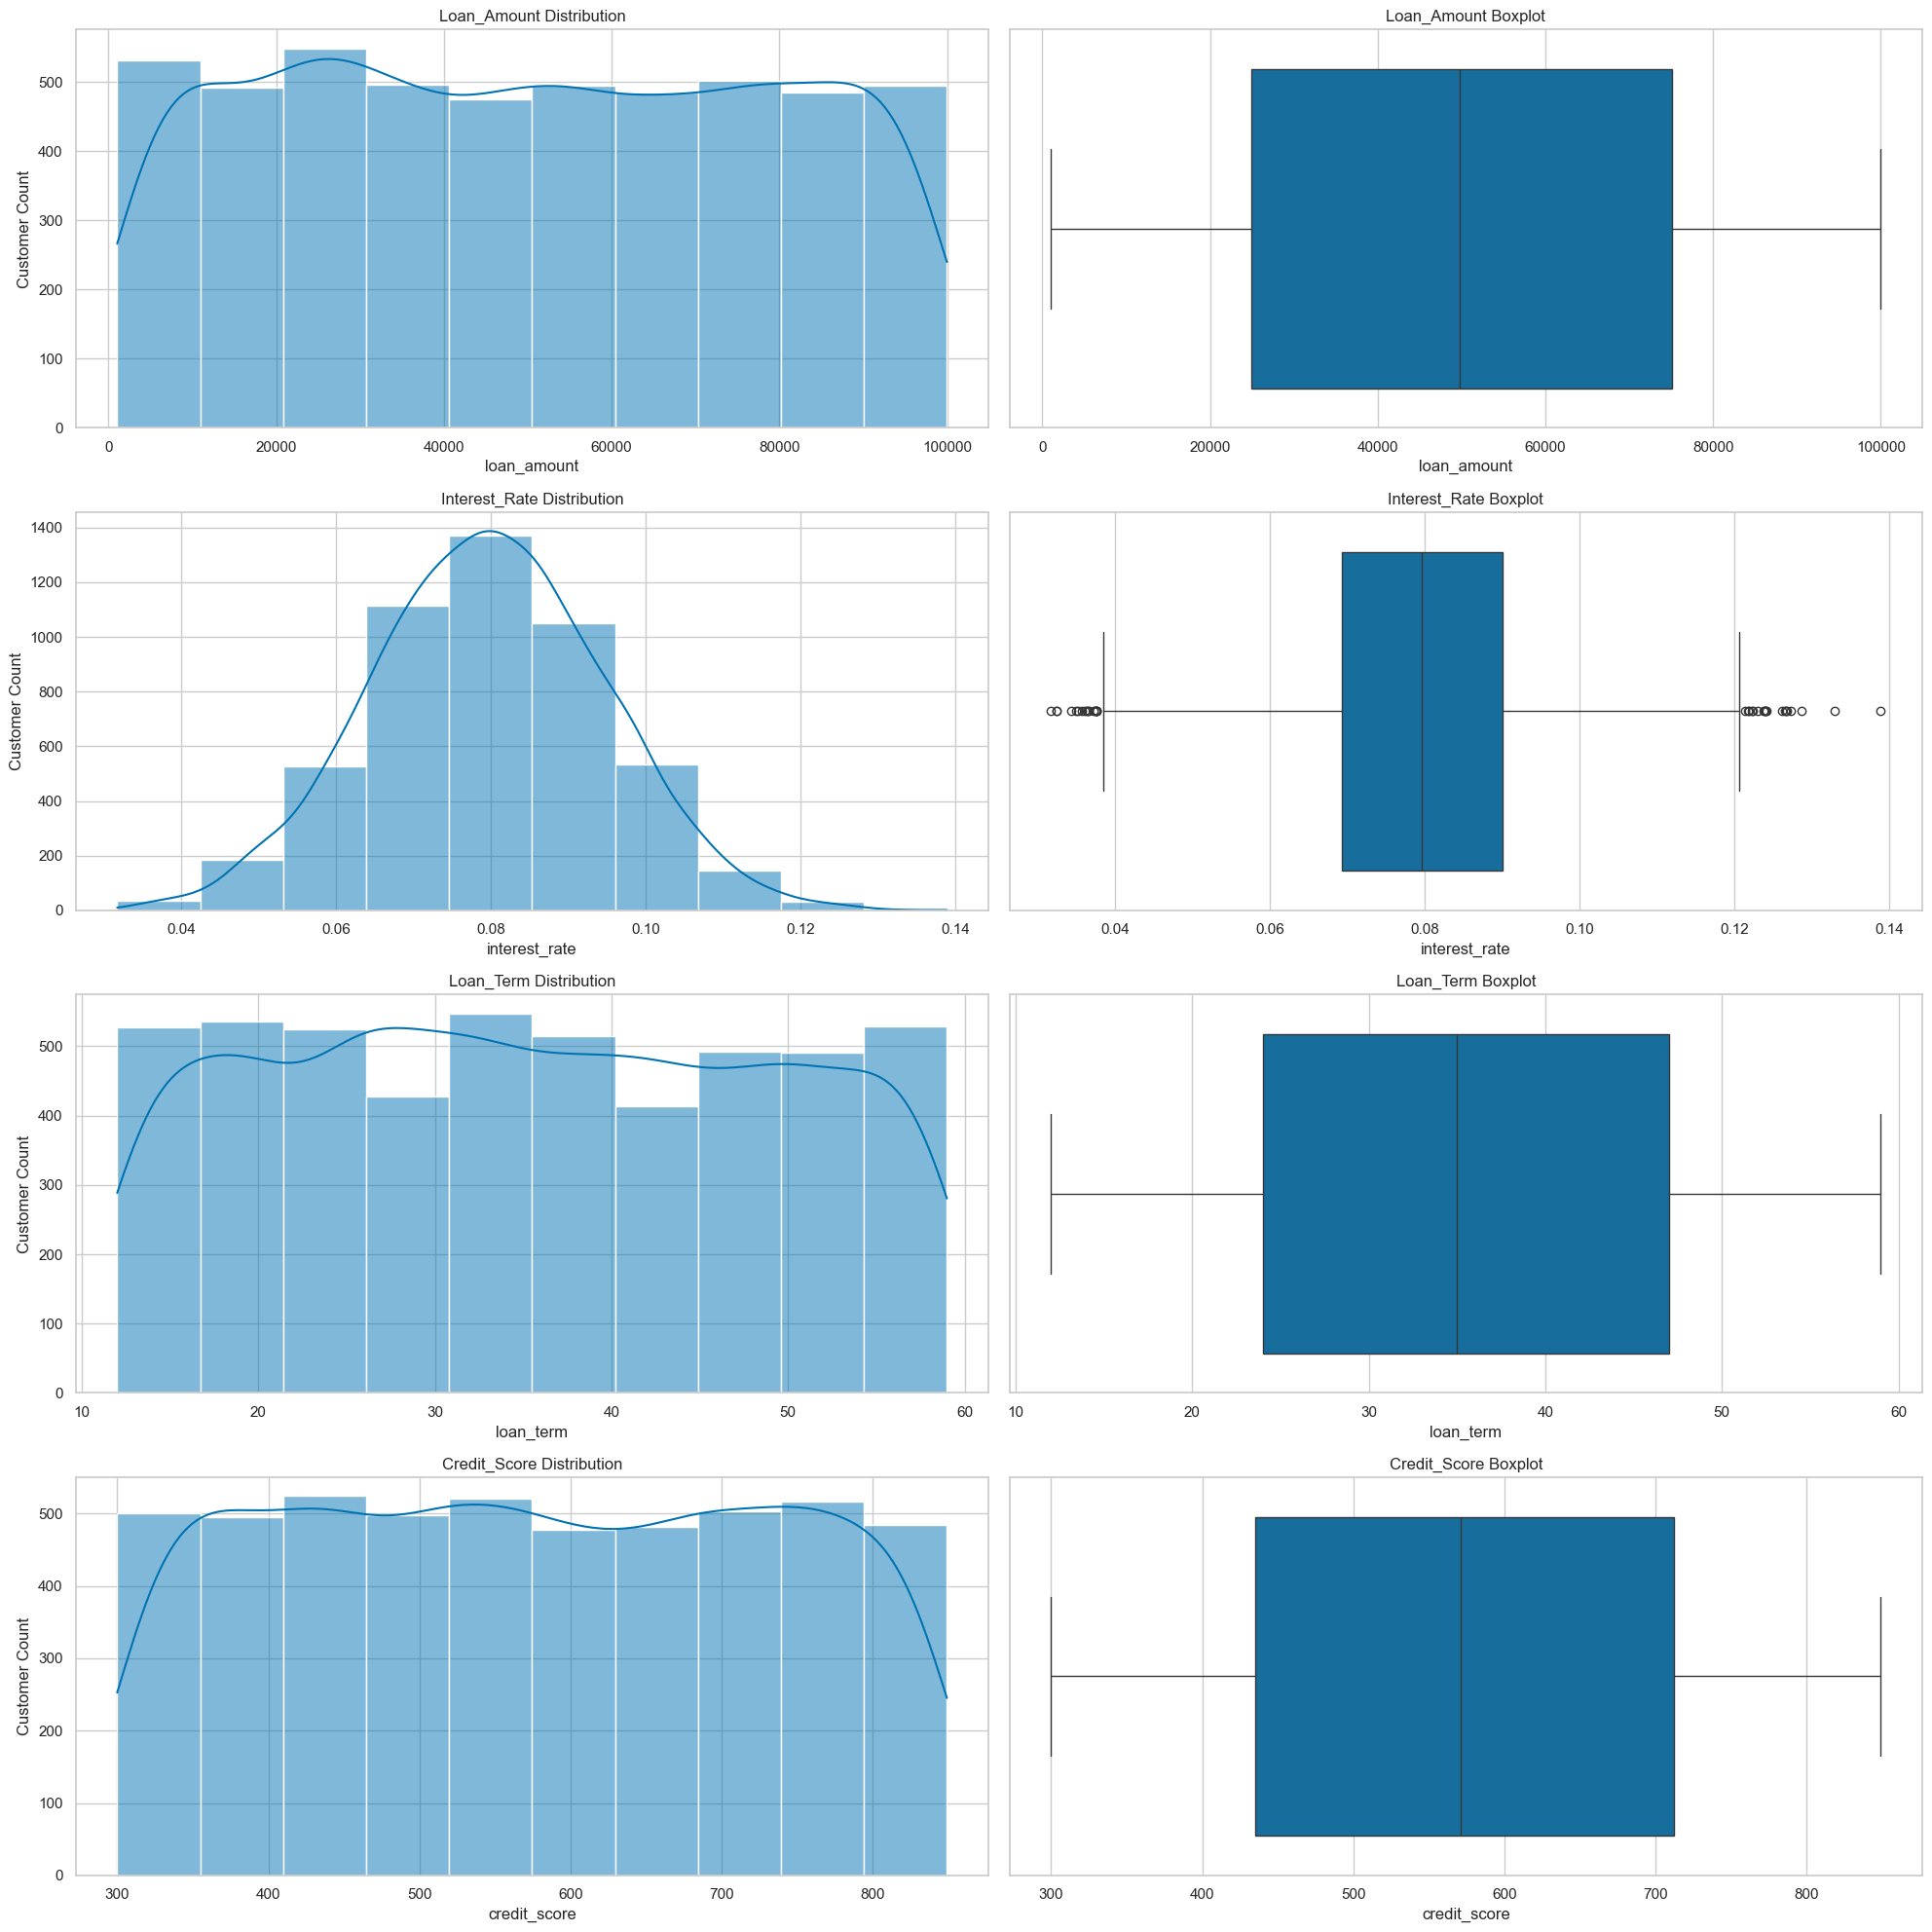

In [12]:
# Explore numeric variables
num_cols = loan_df.select_dtypes(include="number").columns
n_row = len(num_cols)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(20, 5 * n_row))

for i, col in enumerate(num_cols):
    sns.histplot(data=loan_df, x=col, bins=10, kde=True, ax=axs[i, 0]).set(
        xlabel=col, ylabel="Customer Count", title=f"{col.title()} Distribution"
    )

    sns.boxplot(data=loan_df, x=col, ax=axs[i, 1]).set(
        xlabel=col, title=f"{col.title()} Boxplot"
    )

plt.tight_layout()

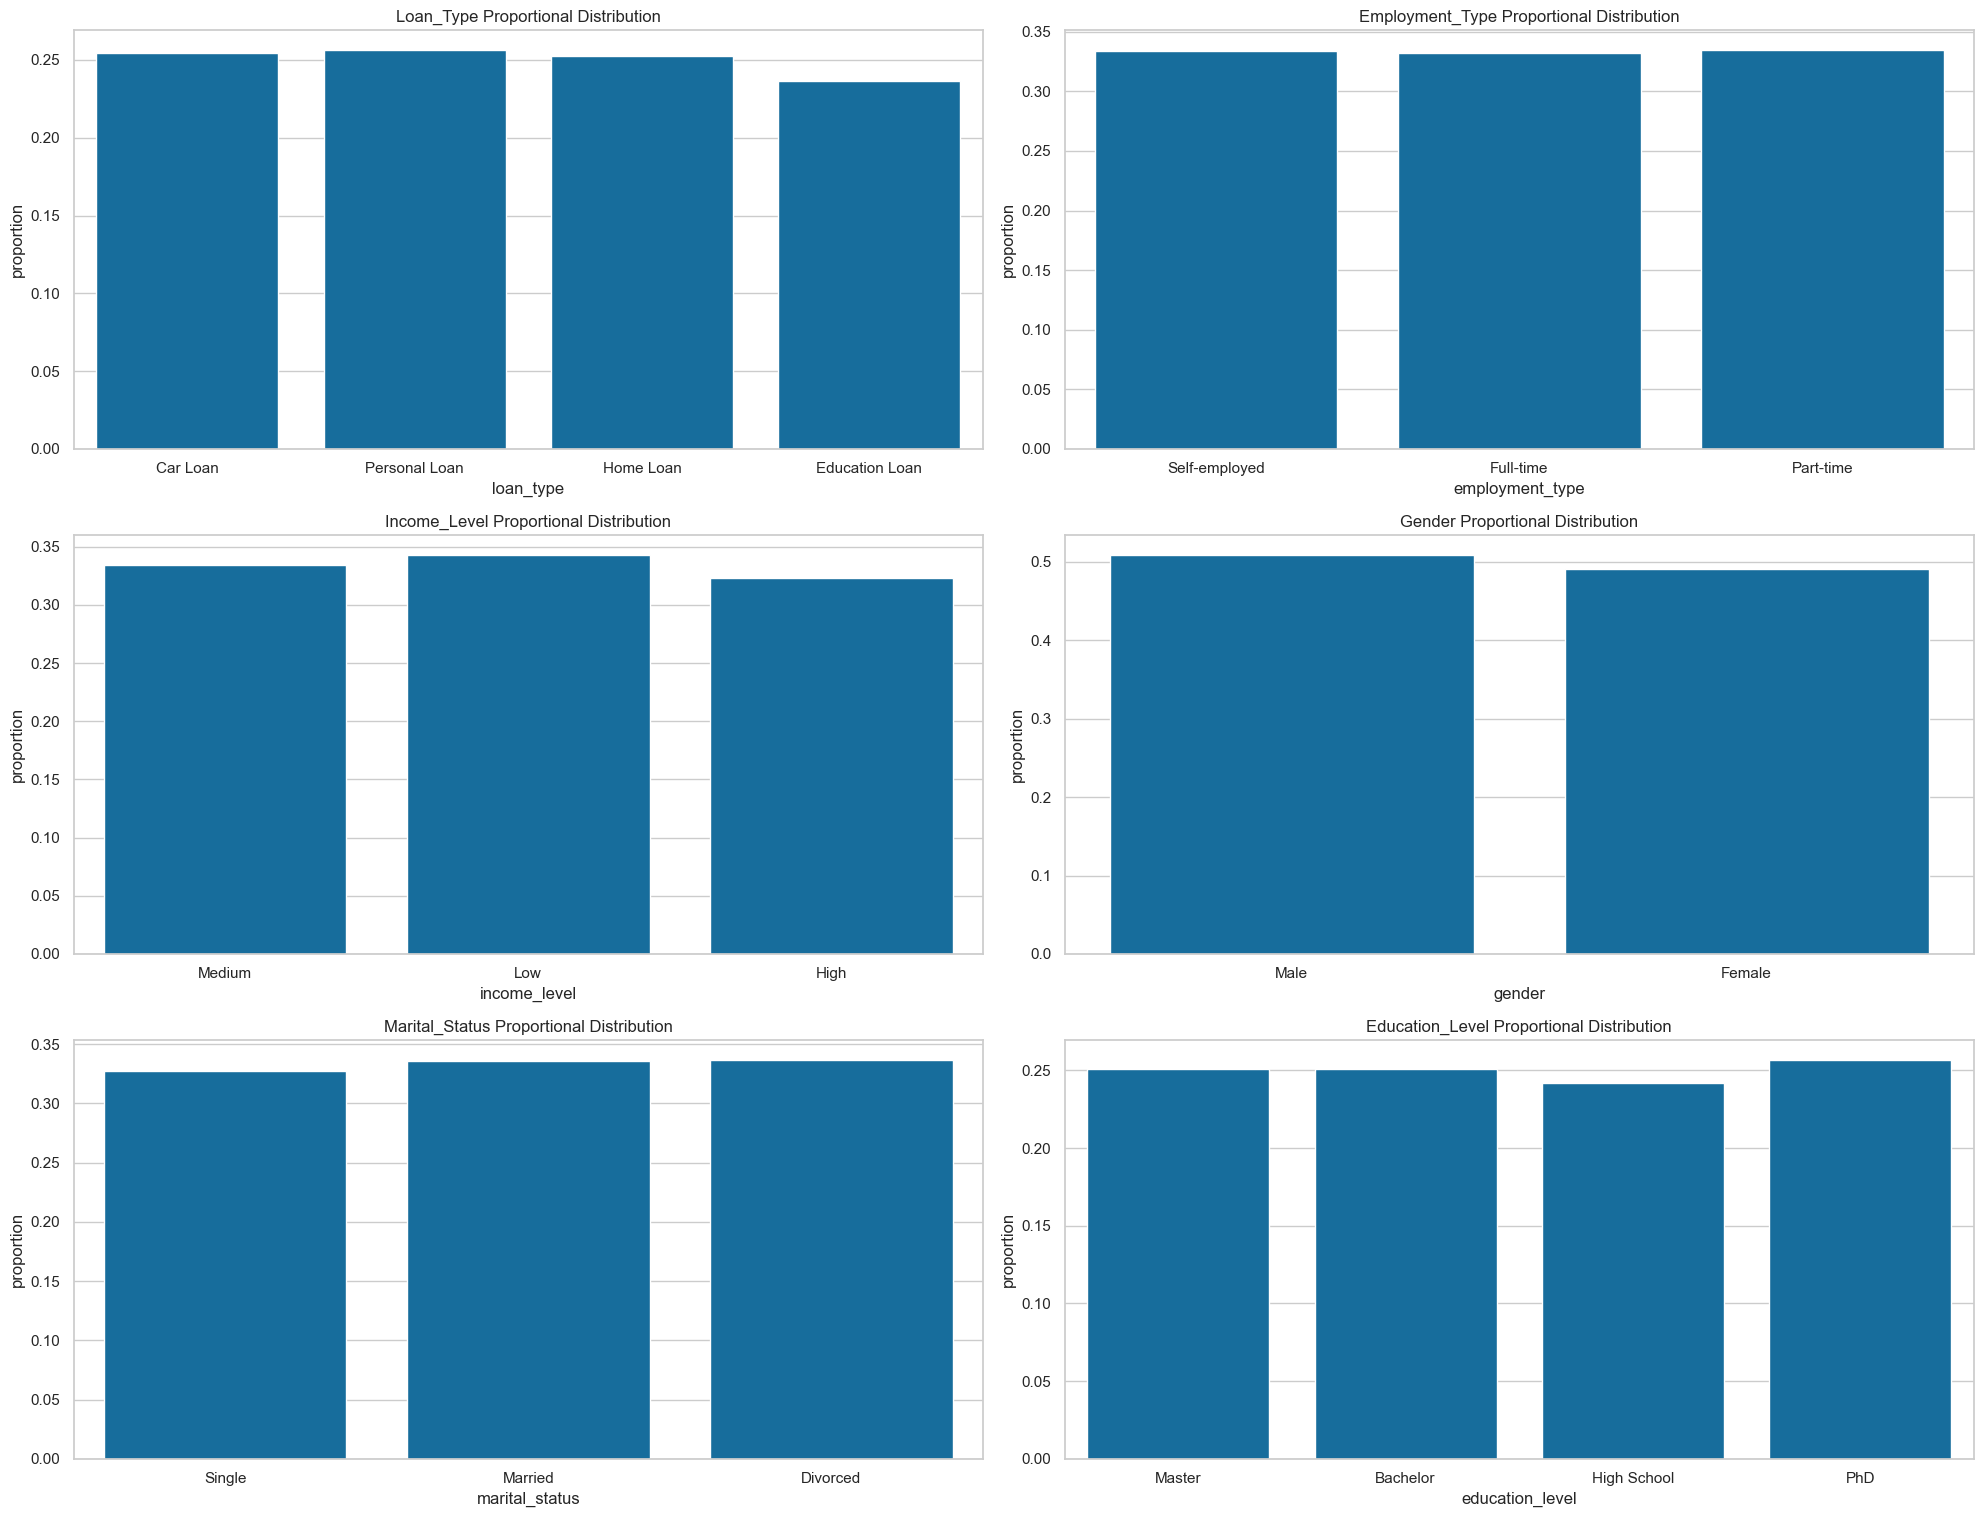

In [13]:
# Explore catgeorical variables
n_row = len(cat_col)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(20, 5 * n_row))
axs = axs.flatten()

for ax, col in zip(axs, cat_col):
    sns.countplot(data=loan_df, x=col, stat="proportion", ax=ax).set(
        title=f"{col.title()} Proportional Distribution"
    )

# Remove unused axes
for ax in axs[len(cat_col):]:
    ax.remove()
    
plt.tight_layout()

## Feature-Target Relationship
### Numeric

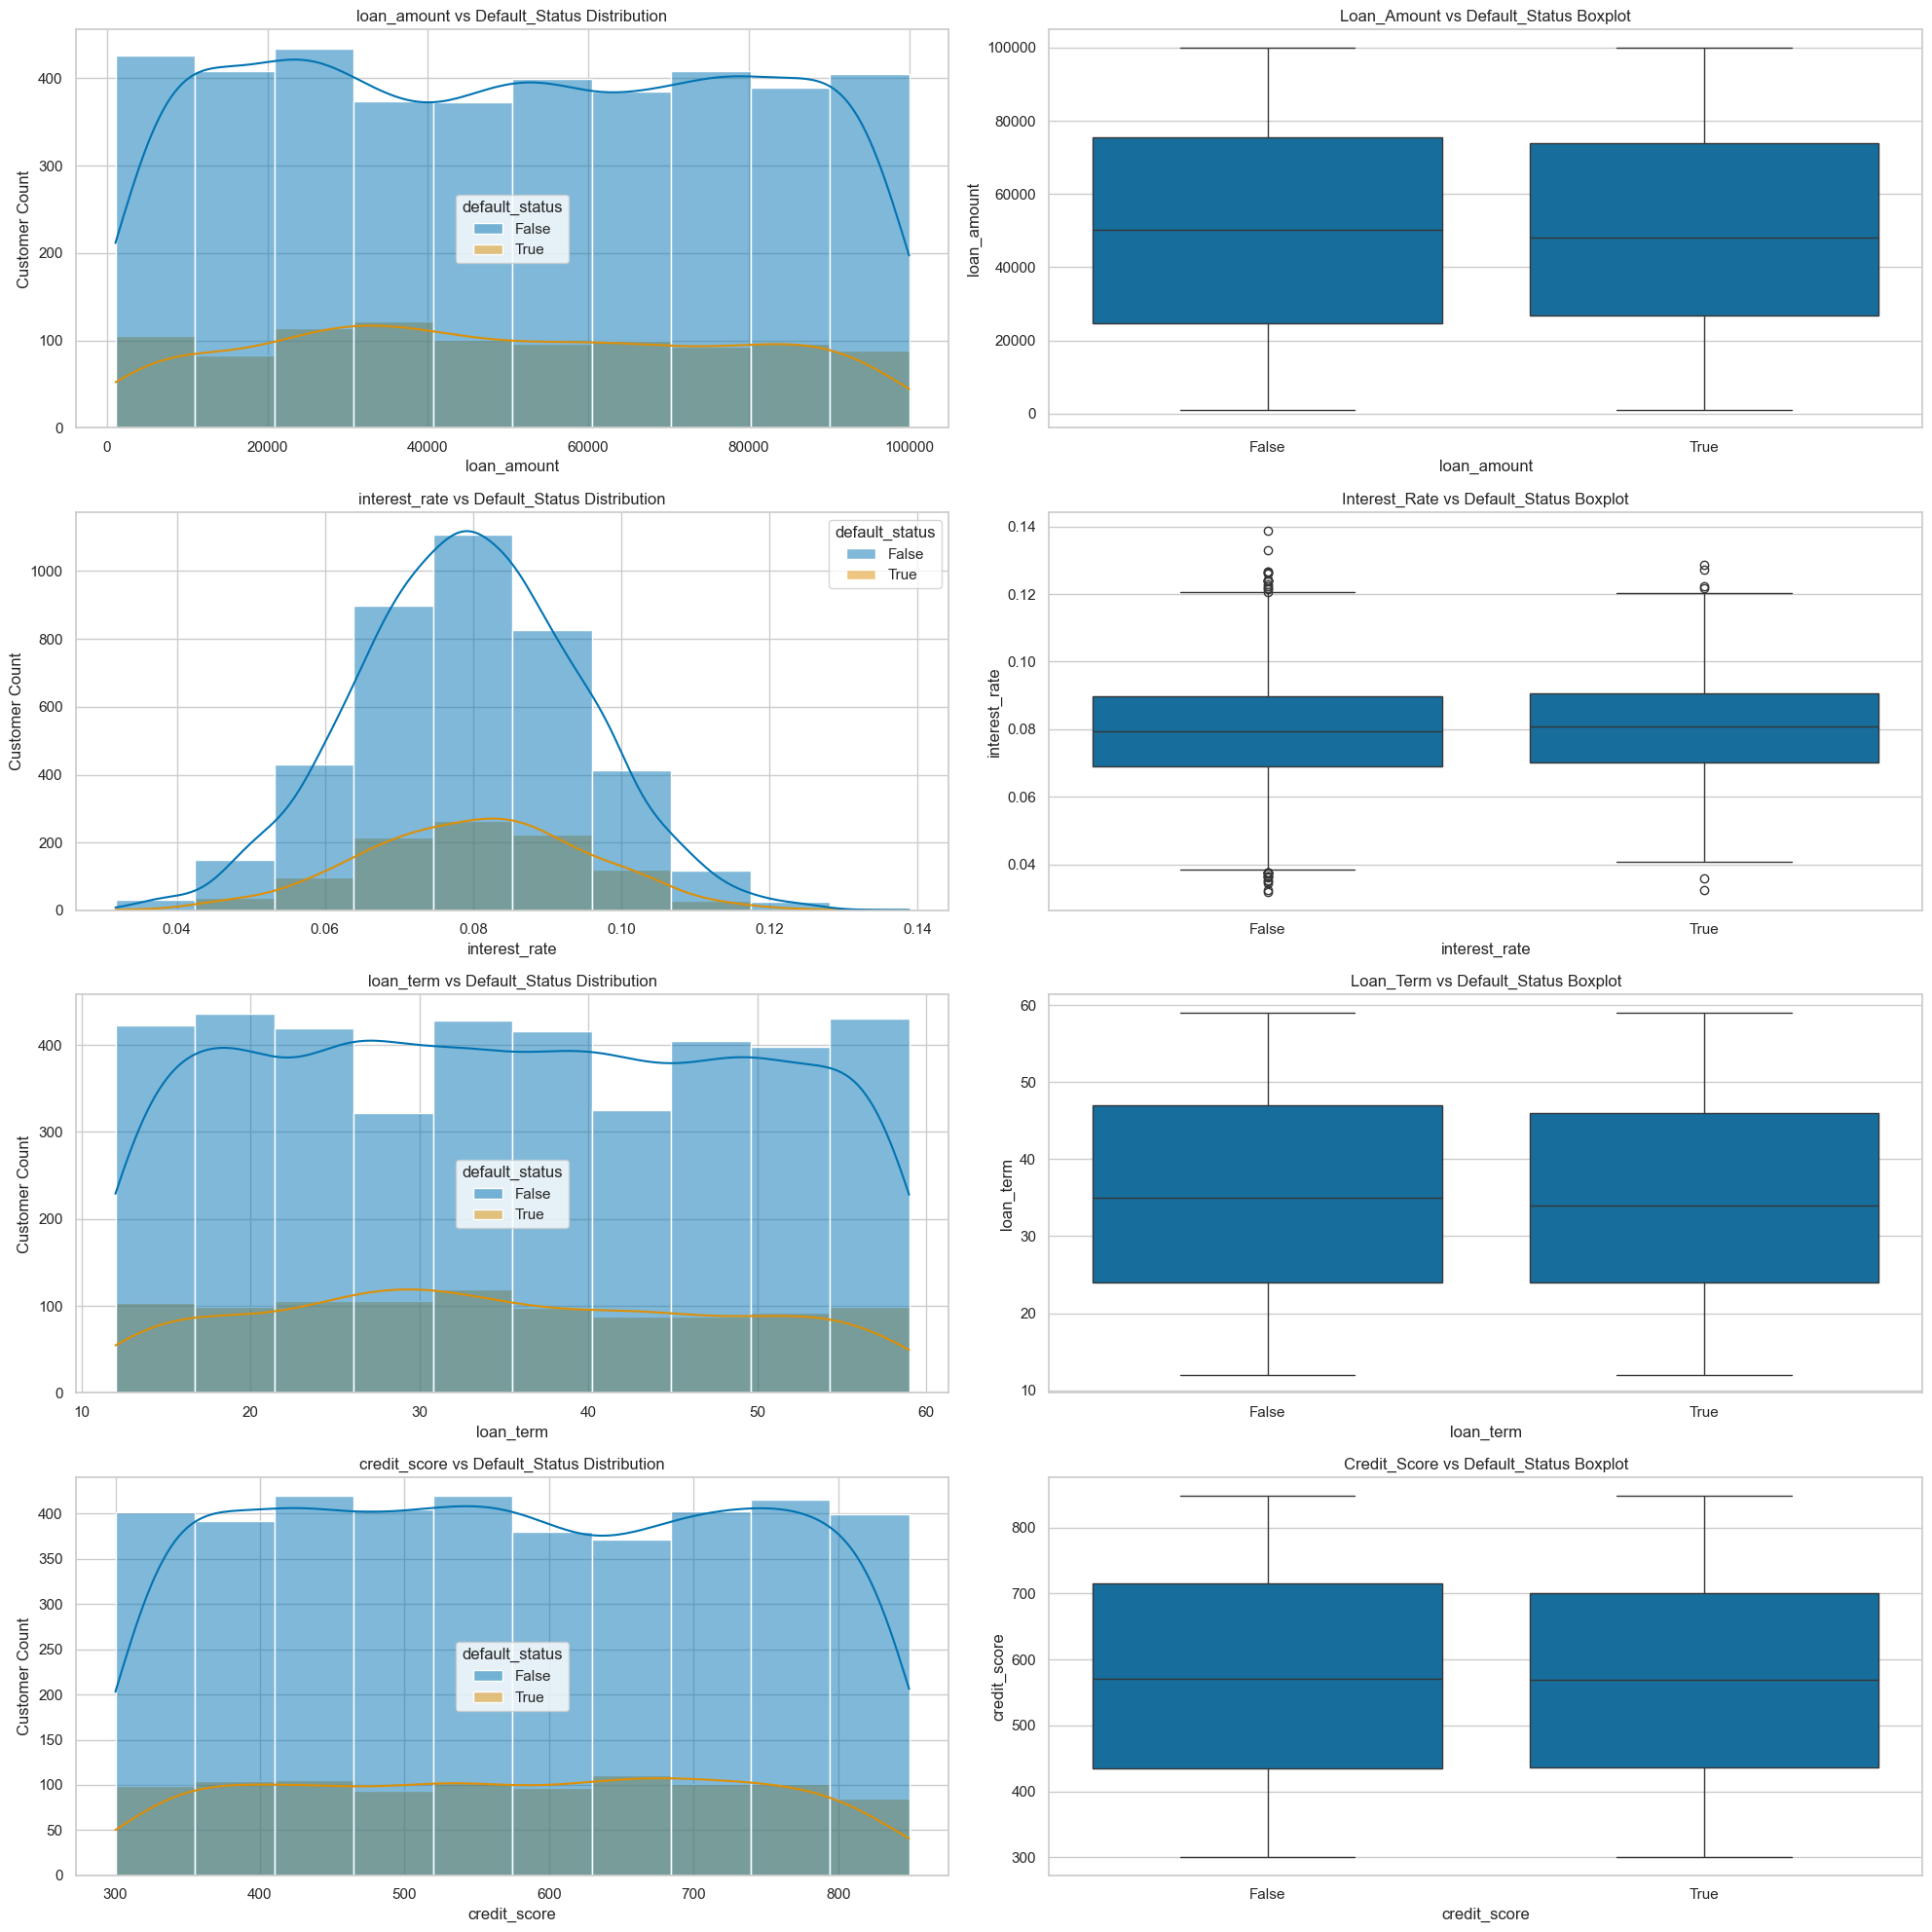

In [14]:
# Explore numeric variables
n_row = len(num_cols)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(20, 5 * n_row))

for i, col in enumerate(num_cols):
    sns.histplot(data=loan_df, x=col, kde=True, bins=10, hue="default_status", ax=axs[i, 0]).set(
        xlabel=col, ylabel="Customer Count", title=f"{col} vs Default_Status Distribution"
    )

    sns.boxplot(data=loan_df, x="default_status", y=col, ax=axs[i, 1]).set(
        xlabel=col, title=f"{col.title()} vs Default_Status Boxplot"
    )

plt.tight_layout()

### Catgeorical

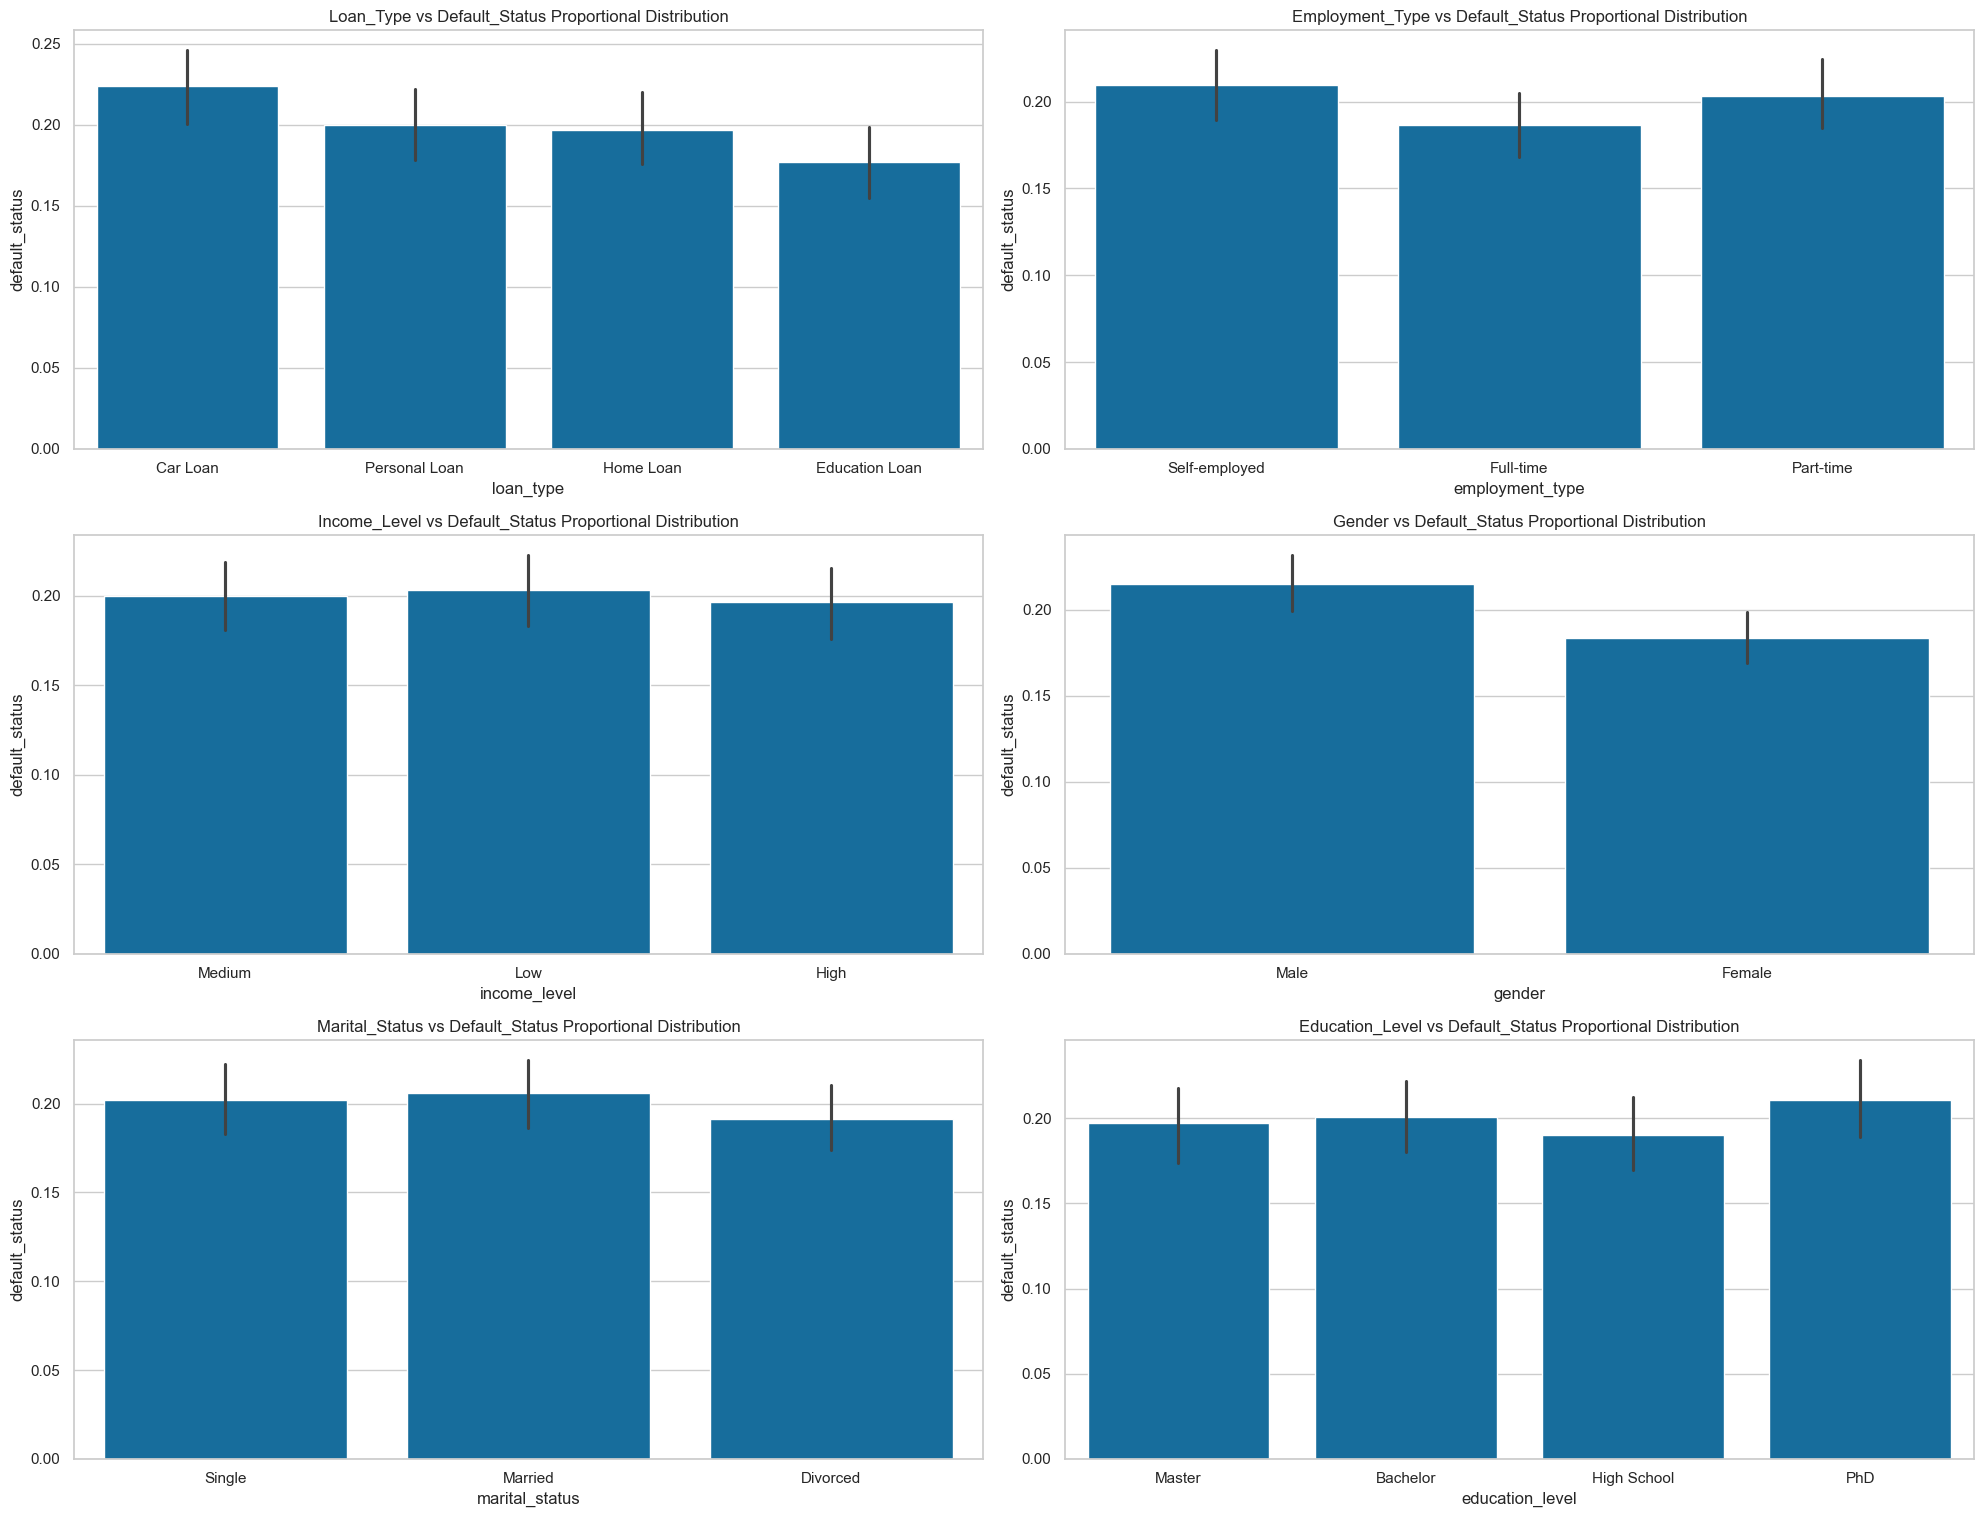

In [15]:
n_row = len(cat_col)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(20, 5 * n_row))
axs = axs.flatten()

for ax, col in zip(axs, cat_col):
    sns.barplot(data=loan_df, y="default_status", x=col, ax=ax).set(
        title=f"{col.title()} vs Default_Status Proportional Distribution"
    )

# remove unused axes
for ax in axs[len(cat_col):]:
    ax.remove()
    
plt.tight_layout()

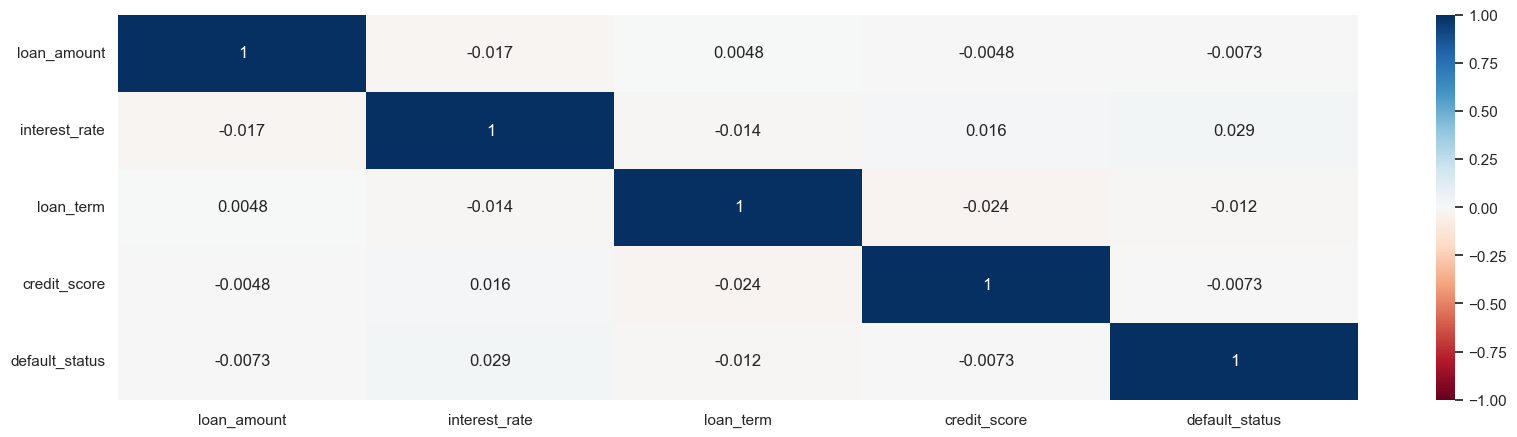

In [16]:
# check for correlation
plt.figure(figsize=(20, 5))
sns.heatmap(loan_df.corr(numeric_only=True), vmin=-1, vmax=1, cmap="RdBu", annot=True);

In [17]:
loan_df.to_csv("../DATA/RAW/loan_cleaned.csv", index=False)